# Data

## Visualize

In [4]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport

In [5]:
df = pd.read_csv("../PreviousDataset.csv")
df.sample(4)

,ID,Latitude_Degrees,Longitude_Degrees,Ocean,Realm,Ecoregion,Country_Name,State_Island_Province,City_Town,City_Town_2,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
1009,4254,-18.688806,146.691806,Pacific,Central Indo-Pacific,Central and northern Great Barrier Reef,Australia,Queensland,Palm Islands,nd,...,2.82,-3.04,1,1.55,6,1,0,1.39,9.14,0.53
2910,6212,-17.794167,177.202222,Pacific,Central Indo-Pacific,Fiji,Fiji,Mamanuca Islands,Malolo Lailai Islands,Black Rock,...,2.14,-1.63,0,1.36,5,1,0,0.95,6.68,0.33
8518,11921,-10.281667,166.267500,Pacific,Central Indo-Pacific,Vanuatu,Solomon Islands,Temotu,Reef Islands,Matumbi Reef,...,2.94,-0.74,1.125,2.09375,9.375,1.5,0.42875,1.475,10.5475,0.6675
4426,7775,-8.337639,116.037639,Indian,Central Indo-Pacific,Lesser Sunda Islands and Savu Sea,Indonesia,West Nusa Tenggara,North Lombok Regency,Gili Islands,...,2.87,-0.98,2,1.78,8,2,0,1.32,8.06,0.67


In [6]:
# profile = ProfileReport(df, title="Coral-Blenching")
# profile.to_notebook_iframe()

In [7]:
df.columns

Index(['ID', 'Latitude_Degrees', 'Longitude_Degrees', 'Ocean', 'Realm',
       'Ecoregion', 'Country_Name', 'State_Island_Province', 'City_Town',
       'City_Town_2', 'City_Town_3', 'Date', 'Date2', 'Depth',
       'Average_Bleaching', 'ClimSST', 'Temperature_Kelvin',
       'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation',
       'TSA_DHWMax', 'TSA_DHWMean'],
      dtype='object')

## Data Cleasing

In [8]:
# coerce numeric columns ที่อาจมี string ปนมา
numeric_cols = ['SSTA', 'ClimSST', 'Depth', 'Longitude_Degrees',
                'Latitude_Degrees', 'Average_Bleaching', 'Windspeed',
                'TSA', 'TSA_DHW', 'SSTA_DHW', 'SSTA_Minimum']

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# parse Date เพื่อใช้กรองปี
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

print(f"Year range: {df['Year'].min():.0f}-{df['Year'].max():.0f}")
print(f"Year distribution:")
print(df['Year'].value_counts().sort_index())

Year range: 1998-2017
Year distribution:
Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
Name: count, dtype: int64


In [9]:
print(f"Before SSTA filter: {len(df)}")
df = df[df['SSTA'] > 0]   # strict > 0 จะได้ 6,112 ตรงกับ paper
print(f"After SSTA > 0: {len(df)}")

df = df[df['Year'] >= 2003]
print(f"After Year >= 2003: {len(df)}")

drop_cols = ['City_Town', 'City_Town_2', 'City_Town_3', 'Ocean', 'Realm', 'Ecoregion', 'ID', 'Country_Name', 'State_Island_Province', 
             'Date2', 'SSTA_Mean', 'Year'] # SSTA_Mean all val = 0

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df = df.dropna(axis=1)
print(f"After drop NaN target: {len(df)}")

print(f"\n>>> Cleaned shape: {df.shape}  (paper reports 6,112)")

Before SSTA filter: 9665
After SSTA > 0: 6162
After Year >= 2003: 6112
After drop NaN target: 6112

>>> Cleaned shape: (6112, 36)  (paper reports 6,112)


In [10]:
df['Month'] = df['Date'].dt.month

# Cyclical encoding — tells model Dec and Jan are close
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Then drop raw Month
df = df.drop(columns=['Month', 'Date'])

In [11]:
# profile_clean = ProfileReport(df, title="Coral-Blenching")
# profile_clean.to_notebook_iframe()

## StandardScaler 

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
X = df.drop("Average_Bleaching", axis = 1)
Y = df["Average_Bleaching"]

In [14]:
scaler = StandardScaler()
X_ss = scaler.fit_transform(X)
X_ss = pd.DataFrame(X_ss, columns=X.columns, index=X.index)
X_ss.head(4)

,Latitude_Degrees,Longitude_Degrees,Depth,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,...,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Month_sin,Month_cos
0,-1.613584,0.937994,-0.712675,0.260855,0.023928,-1.341011,-1.446204,-0.863489,1.523668,0.20817,...,0.269102,0.085255,-0.397128,-0.085116,0.885321,-0.094470,-0.466199,-0.070013,1.584744,0.212262
1,-1.613154,0.938131,-0.424282,0.260855,0.023928,-1.341011,-1.446204,-0.863489,1.523668,0.20817,...,0.269102,0.085255,-0.397128,-0.085116,0.885321,-0.094470,-0.466199,-0.070013,1.584744,0.212262
2,-1.603802,0.938657,-0.135888,0.286739,-0.114745,-1.242965,-1.175310,-0.925276,1.294637,0.20817,...,-0.427501,-0.577623,-0.884924,-0.085116,0.161897,-0.209259,-0.677695,-0.100386,1.584744,0.212262
3,-1.603287,0.938584,-0.424282,0.289394,-0.028672,-1.225662,-1.410560,-0.733048,1.227275,0.20817,...,-0.079200,-0.798583,-0.884924,-0.085116,0.467822,-0.438837,-0.765343,-0.232002,1.584744,0.212262


## PCA

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [16]:
# 1. Fit PCA on all features first to find optimal components
pca = PCA()
X_pca = pca.fit_transform(X_ss)

<Figure size 800x550 with 0 Axes>

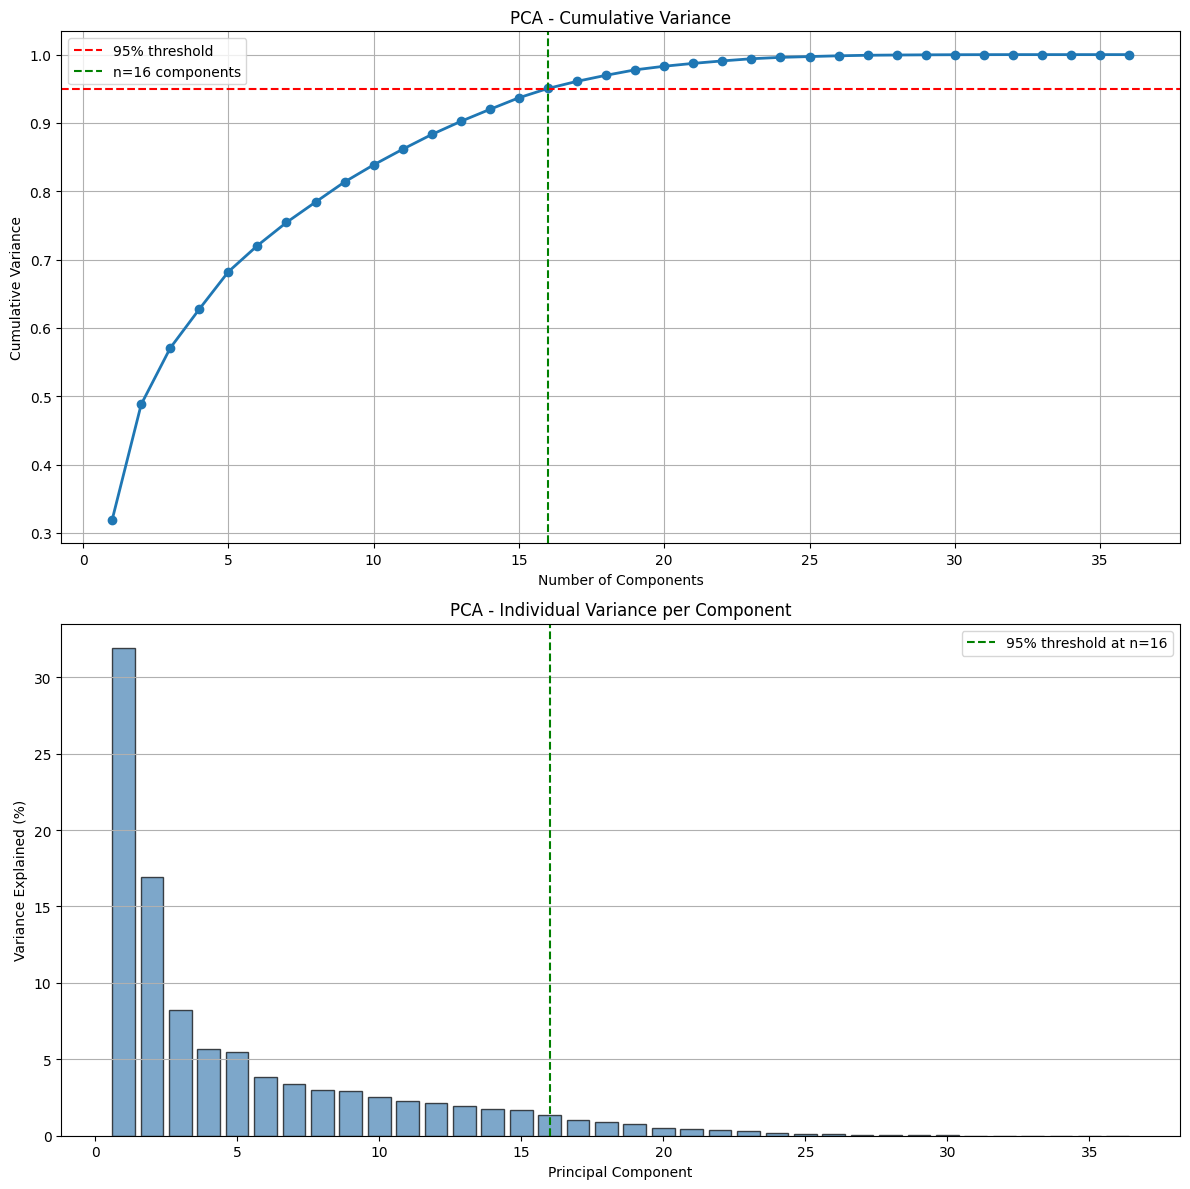

✅ Components needed for 95% variance: 16
✅ Variance explained by 16 components: 0.9505


In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax1.axvline(x=n_components_95, color='g', linestyle='--', 
            label=f'n={n_components_95} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_95, color='g', linestyle='--',
            label=f'95% threshold at n={n_components_95}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 95% variance: {n_components_95}")
print(f"✅ Variance explained by {n_components_95} components: {cumvar[n_components_95-1]:.4f}")

In [18]:
# 3. Find minimum components for 95%
n_components = (cumvar >= 0.95).argmax() + 1
print(f"Components needed for 95% variance: {n_components}")

Components needed for 95% variance: 16


In [19]:
# PCA Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# Show only first n_components_95 columns
loadings_95 = loadings.iloc[:, :n_components_95]

# Sort by absolute loading for each PC
print("\n--- Top features per Principal Component ---")
for col in loadings_95.columns:
    top_features = loadings_95[col].abs().sort_values(ascending=False).head(5)
    print(f"\n{col}:")
    for feat, val in top_features.items():
        print(f"  {feat:35s} {val:.3f}")


--- Top features per Principal Component ---

PC1:
  SSTA_Standard_Deviation             0.279
  SSTA_DHWMean                        0.278
  SSTA_DHW_Standard_Deviation         0.277
  SSTA_FrequencyMean                  0.267
  SSTA_DHWMax                         0.234

PC2:
  TSA_Mean                            0.357
  Temperature_Minimum                 0.308
  Temperature_Mean                    0.302
  TSA_Minimum                         0.297
  Temperature_Kelvin_Standard_Deviation 0.291

PC3:
  Temperature_Maximum                 0.379
  Temperature_Kelvin                  0.361
  Windspeed                           0.290
  SSTA_Frequency_Standard_Deviation   0.271
  TSA_DHWMean                         0.271

PC4:
  SSTA_DHW                            0.394
  SSTA_Frequency                      0.392
  SSTA                                0.306
  TSA_Maximum                         0.289
  TSA_DHW                             0.282

PC5:
  SSTA_FrequencyMax                   0.45

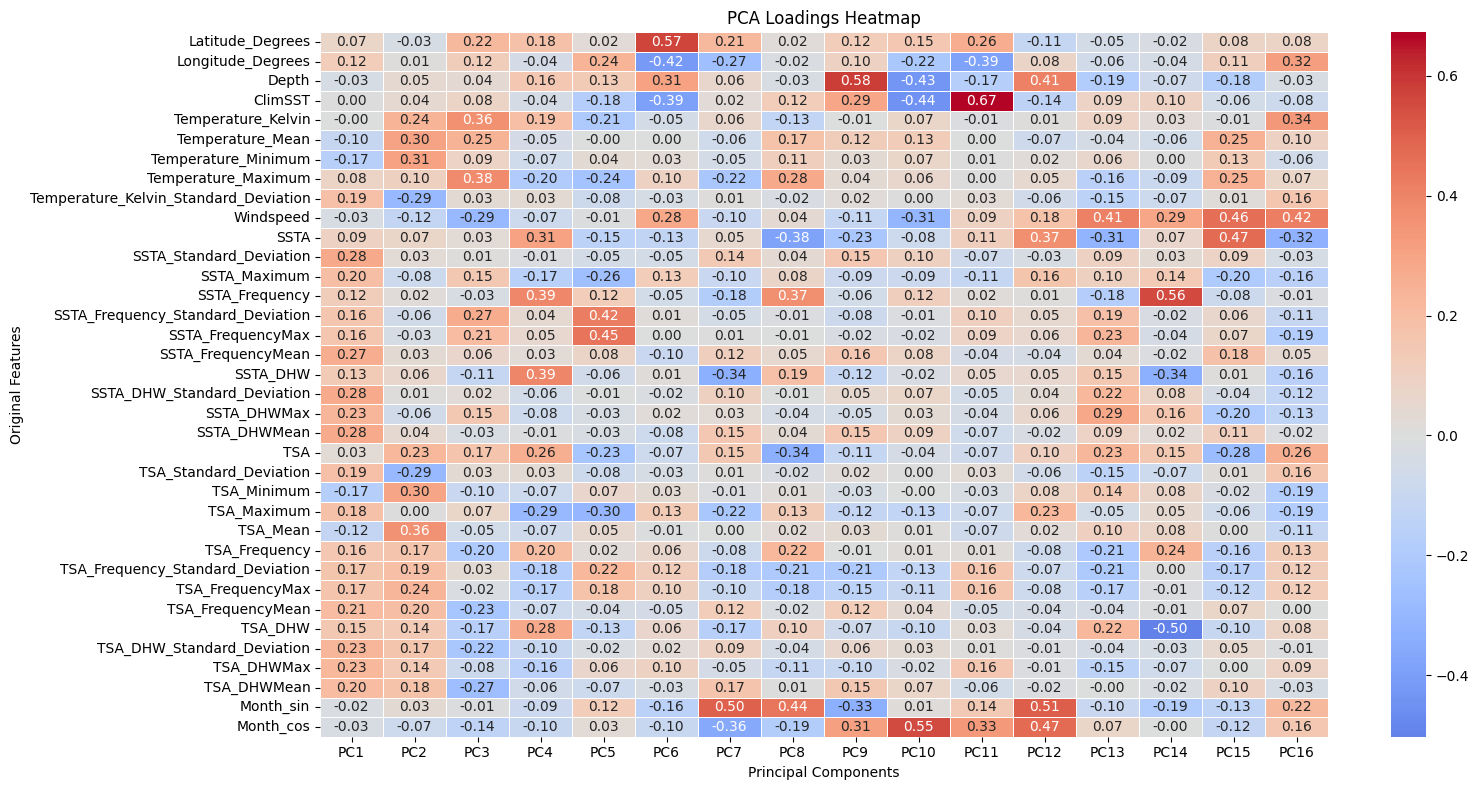

In [20]:
plt.figure(figsize=(16, 8))
sns.heatmap(
    loadings_95,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('PCA Loadings Heatmap')
plt.xlabel('Principal Components')
plt.ylabel('Original Features')
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
X_pca_16 = X_pca[:, 0:16]
X_pca_16

array([[ 1.44545256, -2.43404201, -0.78413158, ..., -0.49352301,
        -0.30127664,  1.30491444],
       [ 1.4358036 , -2.42080215, -0.77189739, ..., -0.51280346,
        -0.35376097,  1.2964995 ],
       [ 0.29693503, -2.69049492, -0.54585371, ..., -0.45456767,
        -0.37909594,  1.0436689 ],
       ...,
       [ 2.25095206, -1.4188896 ,  2.64203949, ..., -0.17166832,
        -1.07545964,  0.0711773 ],
       [ 0.012802  , -0.99544225,  1.81975856, ..., -0.34217044,
         0.97383113,  1.26869361],
       [ 0.05158182, -1.04844831,  1.77125826, ..., -0.26510737,
         1.18397548,  1.30266679]], shape=(6112, 16))

# Train

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_pca_16, Y, test_size=0.2, random_state=67)

In [24]:
model  = xgb.XGBRegressor(
    n_estimators=316, 
    learning_rate=0.02, 
    max_depth=9, 
    subsample=0.7, 
    colsample_bytree=0.9, 
    n_jobs=-1,
    random_state=42
)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [25]:
# คำนวณ Metric ต่างๆ
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse) # RMSE คือรากที่สองของ MSE

print(f"--- Model Evaluation ---")
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}%")

--- Model Evaluation ---
R-squared Score: 0.3010
Mean Absolute Error (MAE): 3.3022%
Root Mean Squared Error (RMSE): 7.8695%


In [26]:
model = RandomForestRegressor(
    n_estimators=131, 
    max_depth=28, 
    min_samples_leaf=1,
    max_features='log2',
    n_jobs=-1, 
    random_state=42
)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [27]:
# คำนวณ Metric ต่างๆ
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse) # RMSE คือรากที่สองของ MSE

print(f"--- Model Evaluation ---")
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}%")

--- Model Evaluation ---
R-squared Score: 0.2946
Mean Absolute Error (MAE): 3.4833%
Root Mean Squared Error (RMSE): 7.9058%
